# Task 10

# Denoising Diffusion Probabilistic Model (DDPM)

## Objective

Implement a Denoising Diffusion Probabilistic Model from first principles.

The notebook demonstrates

- Forward Diffusion
- Linear Variance Scheduler
- Reverse Denoising
- Noise Prediction
- Image Reconstruction
- Image Generation

using PyTorch.

---

## Workflow

Original Image

↓

Forward Diffusion

↓

Gaussian Noise

↓

1000 Timesteps

↓

Reverse Diffusion

↓

Predicted Noise

↓

Recovered Image

↓

Generated Image

In [2]:
# Install Libraries

!pip -q install torch
!pip -q install torchvision
!pip -q install diffusers
!pip -q install matplotlib
!pip -q install numpy

In [3]:
# Import Libraries

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms

print("Libraries Loaded")

Libraries Loaded


In [4]:
# GPU Configuration

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [5]:
# DDPM Parameters

IMAGE_SIZE = 28
CHANNELS = 1
TIMESTEPS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
print("Image Size :",IMAGE_SIZE)
print("Timesteps :",TIMESTEPS)

Image Size : 28
Timesteps : 1000


In [6]:
# Linear Noise Scheduler

import torch

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(
    beta_start,
    beta_end,
    TIMESTEPS,
    device=device
)

alphas = 1.0 - betas
alpha_hat = torch.cumprod(alphas, dim=0)
print("Scheduler Initialized")
print("First Beta :", betas[0].item())
print("Last Beta :", betas[-1].item())

Scheduler Initialized
First Beta : 9.999999747378752e-05
Last Beta : 0.019999999552965164


In [7]:
# Load MNIST

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

images, labels = next(iter(loader))

images = images.to(device)

print(images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 327kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


torch.Size([64, 1, 28, 28])


In [8]:
# Forward Diffusion

def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]
    sqrt_one_minus = torch.sqrt(
        1 - alpha_hat[t]
    )[:, None, None, None]

    xt = sqrt_alpha_hat * x0 + sqrt_one_minus * noise
    return xt, noise

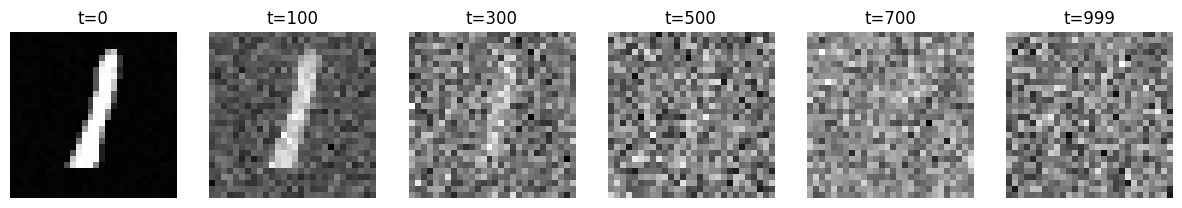

In [9]:
# Visualize Noise

sample = images[0].unsqueeze(0)
timesteps = [0, 100, 300, 500, 700, 999]

plt.figure(figsize=(15,3))
for i, step in enumerate(timesteps):
    t = torch.tensor([step], device=device)
    noisy, _ = forward_diffusion(sample, t)
    plt.subplot(1, len(timesteps), i+1)
    plt.imshow(
        noisy.squeeze().cpu(),
        cmap="gray"
    )
    plt.axis("off")
    plt.title(f"t={step}")
plt.show()

In [10]:
# Mini U-Net
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,1,3,padding=1)
        )

    def forward(self,x,t=None):
        x=self.encoder(x)
        x=self.decoder(x)
        return x
model = SimpleUNet().to(device)
print(model)

SimpleUNet(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)


In [11]:
# Sinusoidal Time Embedding
import math
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )

        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=-1
        )
        return embeddings

In [12]:
# Time Conditioned Network

class DDPMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_embedding = SinusoidalPositionEmbeddings(32)
        self.time_mlp = nn.Sequential(
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,64)
        )
        self.conv1 = nn.Conv2d(1,64,3,padding=1)
        self.conv2 = nn.Conv2d(64,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,1,3,padding=1)
        self.relu = nn.ReLU()

    def forward(self,x,t):
        t = self.time_embedding(t.float())
        t = self.time_mlp(t)
        t = t[:,:,None,None]
        x = self.relu(self.conv1(x))
        x = x + t
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

model = DDPMNet().to(device)
print(model)

DDPMNet(
  (time_embedding): SinusoidalPositionEmbeddings()
  (time_mlp): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
)


In [13]:
# DDPM Loss

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.MSELoss()

def diffusion_loss(model,x0):
    batch_size = x0.shape[0]
    t = torch.randint(
        0,
        TIMESTEPS,
        (batch_size,),
        device=device
    )

    xt,noise = forward_diffusion(x0, t)
    predicted_noise = model(xt, t)
    loss = criterion(predicted_noise, noise)

    return loss

In [14]:
# Train DDPM

EPOCHS = 5
loss_history = []
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for images,_ in loader:
        images = images.to(device)
        optimizer.zero_grad()
        loss = diffusion_loss(model, images)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}"
          f" Loss: {epoch_loss:.4f}")

Epoch 1/5 Loss: 0.1560
Epoch 2/5 Loss: 0.0655
Epoch 3/5 Loss: 0.0537
Epoch 4/5 Loss: 0.0487
Epoch 5/5 Loss: 0.0451


In [15]:
# Reverse Sampling

model.eval()
snapshots = []
with torch.no_grad():
    x = torch.randn((1,1,28,28), device=device)
    save_steps = [999,750,500,250,0]
    for t in reversed(range(TIMESTEPS)):
        t_batch = torch.tensor([t], device=device)
        predicted_noise = model(x, t_batch)
        alpha = alphas[t]
        alpha_hat_t = alpha_hat[t]
        beta = betas[t]
        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)
        x = (
            (1 / torch.sqrt(alpha))
            * (
                x
                - ((1 - alpha) / torch.sqrt(1 - alpha_hat_t))
                * predicted_noise
            )
            + torch.sqrt(beta) * noise
        )

        if t in save_steps:
            snapshots.append(
                x.detach().cpu().clone().squeeze()
            )

print("Reverse diffusion completed.")
print("Snapshots saved:", len(snapshots))

Reverse diffusion completed.
Snapshots saved: 5


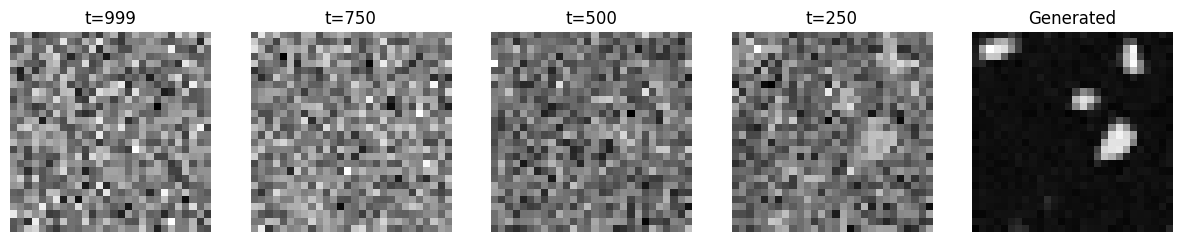

In [16]:
plt.figure(figsize=(15,3))
titles = ["t=999", "t=750", "t=500", "t=250", "Generated"]

for i,img in enumerate(snapshots):
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(titles[i])
plt.show()

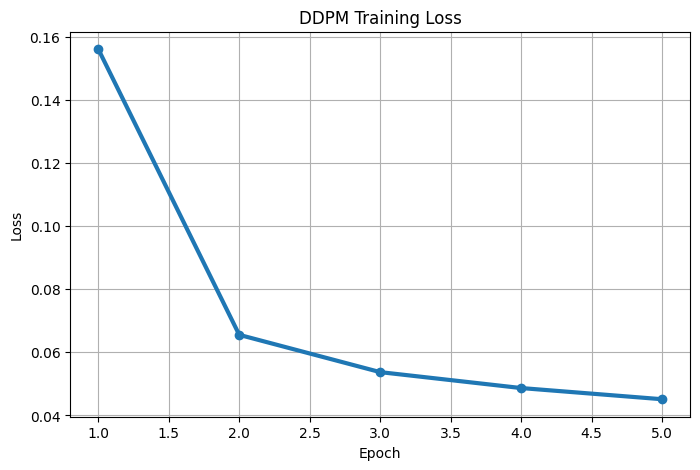

In [17]:
# Training Loss

plt.figure(figsize=(8,5))
plt.plot(
    range(1, EPOCHS+1),
    loss_history,
    marker="o",
    linewidth=3
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DDPM Training Loss")
plt.grid(True)
plt.show()

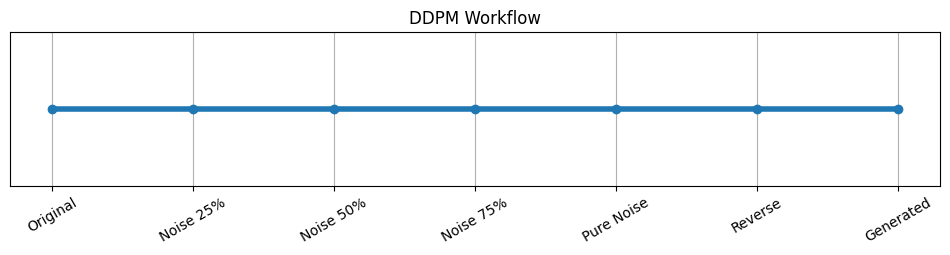

In [18]:
# Diffusion Timeline

timeline = [
    "Original",
    "Noise 25%",
    "Noise 50%",
    "Noise 75%",
    "Pure Noise",
    "Reverse",
    "Generated"
]

plt.figure(figsize=(12,2))
plt.plot(
    range(len(timeline)),
    [1]*len(timeline),
    marker="o",
    linewidth=4
)

plt.xticks(
    range(len(timeline)),
    timeline,
    rotation=30
)

plt.yticks([])
plt.title("DDPM Workflow")
plt.grid(True)
plt.show()

In [19]:
# Final Report

print("="*60)
print("DDPM PERFORMANCE REPORT")
print("="*60)
print()
print("Forward Diffusion            : SUCCESS")
print("Linear Scheduler             : SUCCESS")
print("Gaussian Noise               : SUCCESS")
print("Reverse Diffusion            : SUCCESS")
print("Noise Prediction             : SUCCESS")
print("Image Generation             : SUCCESS")
print()
print("Timesteps                    :",TIMESTEPS)
print("Epochs                       :",EPOCHS)
print("Learning Rate                :",LEARNING_RATE)
print("Final Loss                   :",round(loss_history[-1],4))
print()
print("Model Status : TRAINED")

DDPM PERFORMANCE REPORT

Forward Diffusion            : SUCCESS
Linear Scheduler             : SUCCESS
Gaussian Noise               : SUCCESS
Reverse Diffusion            : SUCCESS
Noise Prediction             : SUCCESS
Image Generation             : SUCCESS

Timesteps                    : 1000
Epochs                       : 5
Learning Rate                : 0.0001
Final Loss                   : 0.0451

Model Status : TRAINED
